#  — Scalping: many small, fast trades

Every strategy so far holds a position until a NEW signal tells it to change its
mind — the SMA crossover (NB3/NB4) rides a trend until the averages flip, the RSI
mean-reversion strategy (`extras/week1`) rides a bounce until it's no longer
oversold. Both can hold for weeks.

A **scalp** is a different animal. It doesn't wait for the story to change — it
defines success and failure in advance (a profit target and a stop-loss) and
walks away the moment either one is hit, usually within a few days. It trades
often, on purpose, to bank many small, mechanical wins instead of a few large,
opinion-based ones.

Two things you build:
1. `ScalpingStrategy` — enters on a short-term dip below the fast average, exits
   on a fixed profit target / stop-loss / time limit — not on the entry signal
   reversing.
2. A **win rate** metric — the fraction of closed trades that came out ahead —
   the natural complement to `total_return`, `sharpe`, and `max_drawdown` when a
   strategy makes many discrete trades instead of one long holding.

Everything else — `DataFeed`, `build_observation`, `run_backtest`,
`PortfolioSimulator`, `report()`, `metrics` — is reused exactly as built in NB1–4.
No new data loading, no new backtesting engine, no new libraries.

## 1. The idea — trading the wiggle, not the trend

`features.py` already computes, for every stock, every day:
`p/sma_fast = (close / SMA_fast) - 1` — how far today's price sits from its own
short-term average, as a fraction. That's feature 1 of the observation, the same
tensor every strategy this week reads from.

A trend-follower ignores small dips. A scalper is built *for* them: if price has
slipped `entry_dip` below its own fast average, treat it as a short-lived
overreaction — not the start of a new trend — and bet on a quick snap-back.
Nothing here is a new signal; it's the same price-deviation feature used
everywhere else, just read with a different rule.

In [8]:
import sys, os
while not os.path.isdir('src') and os.path.dirname(os.getcwd()) != os.getcwd():
    os.chdir('..')
sys.path.insert(0, 'src')

import numpy as np
import matplotlib.pyplot as plt
from tradinglab.data_feed import DataFeed
from tradinglab.observation import build_observation

feed = DataFeed.from_dir('data/egx', symbols=['COMI', 'HRHO', 'TMGH', 'SWDY', 'FWRY', 'ABUK'])

obs_today = build_observation(feed, feed.n_days - 2, lookback=30)
deviation_today = obs_today[:, -1, 1]   # feature 1 = p/sma_fast, already computed
for sym, dev in zip(feed.symbols, deviation_today):
    tag = 'DIP' if dev < -0.015 else ''
    print(f'{sym:6s}  price vs fast SMA = {dev:+.2%}  {tag}')

COMI    price vs fast SMA = +1.56%  
HRHO    price vs fast SMA = -0.99%  
TMGH    price vs fast SMA = -2.55%  DIP
SWDY    price vs fast SMA = +1.59%  
FWRY    price vs fast SMA = -0.13%  
ABUK    price vs fast SMA = -1.43%  


## 2. Class — `ScalpingStrategy`

Every strategy so far (`sma_crossover_weights`, `rsi_mean_reversion_weights`) is a
plain function: `observation -> weights`, re-deciding fresh every day with no
memory. A scalp can't work that way — "exit when the profit target is hit" only
means something if the strategy remembers what price it entered at and how long
it's been waiting. So `ScalpingStrategy` is a small stateful class instead of a
function; `run_backtest` calls it once per day, in order, exactly like any other
strategy — it just happens to remember things between calls.

**Entry** (per stock, independently): not currently in a trade, and today's price
is `entry_dip` below its fast SMA (feature 1).

**Exit** (per stock, independently) — whichever comes first:
- `profit_target` reached -> take the win
- `stop_loss` reached -> cut the loss
- `max_hold_days` reached -> flatten anyway; a scalp that hasn't resolved by then
  isn't a scalp anymore

**Position sizing:** only stocks *currently in a trade* get capital — everything
else is cash, the same "genuine cash, not a forced bet" principle as
`sma_crossover_weights`. Among open trades, weight is inversely proportional to
`volatility` (feature 4, already computed) and capped at `max_weight_per_asset`,
so one jumpy stock can't dominate the book.

**In:** `observation`, shape `(n_assets, lookback, n_features)`.
**Out:** `weights`, shape `(n_assets,)`, non-negative, summing to at most 1.

In [9]:
class ScalpingStrategy:
    '''Enter on a short-term dip below the fast average; exit on a fixed
    profit target, stop-loss, or time limit -- never on the entry signal
    reversing. State (who's in a trade, at what price, for how long) lives on
    `self` because a scalp's exit depends on its own history, not just today's
    observation.
    '''

    def __init__(self, entry_dip=0.015, profit_target=0.02, stop_loss=0.01,
                 max_hold_days=5, max_weight_per_asset=0.5):
        self.entry_dip = entry_dip
        self.profit_target = profit_target
        self.stop_loss = stop_loss
        self.max_hold_days = max_hold_days
        self.max_weight_per_asset = max_weight_per_asset
        self.trade_log = []          # one entry per CLOSED trade -- for win rate later

        self._price = None           # running scale-free price per asset (see NB3 SS3)
        self._in_position = None
        self._entry_price = None
        self._days_held = None

    def __call__(self, observation):
        n_assets = observation.shape[0]
        if self._price is None:                      # first call: set up state
            self._price = np.ones(n_assets)
            self._in_position = np.zeros(n_assets, dtype=bool)
            self._entry_price = np.zeros(n_assets)
            self._days_held = np.zeros(n_assets, dtype=int)

        # ---8<--- solution
        today_return = observation[:, -1, 0]
        deviation = observation[:, -1, 1]            # p/sma_fast
        vol = observation[:, -1, 4]

        self._price *= (1.0 + today_return)           # roll the price path forward one day

        for asset in range(n_assets):
            if self._in_position[asset]:
                self._days_held[asset] += 1
                trade_return = self._price[asset] / self._entry_price[asset] - 1.0
                hit_target = trade_return >= self.profit_target
                hit_stop = trade_return <= -self.stop_loss
                timed_out = self._days_held[asset] >= self.max_hold_days
                if hit_target or hit_stop or timed_out:
                    reason = 'target' if hit_target else 'stop' if hit_stop else 'timeout'
                    self.trade_log.append({
                        'asset': asset, 'return': trade_return,
                        'days_held': int(self._days_held[asset]), 'reason': reason,
                    })
                    self._in_position[asset] = False
            elif deviation[asset] <= -self.entry_dip:
                self._in_position[asset] = True
                self._entry_price[asset] = self._price[asset]
                self._days_held[asset] = 0

        if not self._in_position.any():
            return np.zeros(n_assets)                 # nothing open -- genuine cash

        inv_vol = np.where(self._in_position, 1.0 / np.maximum(vol, 1e-4), 0.0)
        weights = inv_vol / inv_vol.sum()
        weights = np.minimum(weights, self.max_weight_per_asset)
        weights = weights / weights.sum()             # re-normalize after capping
        return weights
        # ---8<--- end


# check 1: only the dipped asset should be entered
strat = ScalpingStrategy(entry_dip=0.01, profit_target=0.02, stop_loss=0.01, max_hold_days=3)
obs = np.zeros((3, 30, 5)); obs[:, -1, 1] = [-0.02, 0.0, -0.005]   # only asset 0 dipped enough
obs[:, -1, 4] = 0.02
w1 = strat(obs)
assert w1[0] > 0 and w1[1] == 0 and w1[2] == 0, 'should only enter the dipped asset'
print('entry rule correct ✓')

# check 2: a jump past the profit target should close the trade
obs2 = np.zeros((3, 30, 5)); obs2[:, -1, 0] = [0.025, 0.0, 0.0]    # asset 0 jumps +2.5%
w2 = strat(obs2)
assert w2[0] == 0, 'should have taken profit and exited'
assert strat.trade_log[-1]['reason'] == 'target'
print('exit rule correct ✓  (closed on:', strat.trade_log[-1]['reason'], ')')

entry rule correct ✓
exit rule correct ✓  (closed on: target )


## 3. Run it — the same backtester, the same universe

Same six stocks, same `PortfolioSimulator`, same `run_backtest` loop as NB4. A
fresh `ScalpingStrategy()` instance is created right here, in the same cell as
the backtest — its memory of open trades must start empty, so re-running this
cell always starts clean.

In [10]:
from tradinglab.simulator import PortfolioSimulator
from tradinglab.backtester import run_backtest
from tradinglab.charting import plot_price

sim = PortfolioSimulator(feed, benchmark='egx30')
scalper = ScalpingStrategy(entry_dip=0.015, profit_target=0.02, stop_loss=0.01,
                            max_hold_days=5, max_weight_per_asset=0.5)

result = run_backtest(sim, scalper, lookback=30)

print('backtest length      :', len(result['portfolio']), 'days')
print('closed trades        :', len(scalper.trade_log))
print('final portfolio value (starting at 1.0):', round(result['portfolio'][-1], 3))
print('final benchmark value (starting at 1.0):', round(result['benchmark'][-1], 3))

backtest length      : 1662 days
closed trades        : 1211
final portfolio value (starting at 1.0): 1.284
final benchmark value (starting at 1.0): 3.967


## 4. Does it actually trade like a scalper?

`turnover_summary` (built in NB4) already answers "how much trading happened"
from the weights alone. `scalper.trade_log` adds the trade-level view: how many
trades closed, how long each was held, and — the new metric — **win rate**: the
fraction of closed trades that ended in profit.

In [11]:
from tradinglab.charting import turnover_summary

turnover = turnover_summary(result['weights'])
print('total weight changes ("trades")  :', turnover['total_trades'])
print('avg stocks held per day          :', round(turnover['avg_stocks_held'], 2))

trade_returns = np.array([t['return'] for t in scalper.trade_log])
hold_days = np.array([t['days_held'] for t in scalper.trade_log])
reasons = [t['reason'] for t in scalper.trade_log]

win_rate = float((trade_returns > 0).mean()) if len(trade_returns) else 0.0

print(f'\nclosed trades          : {len(trade_returns)}')
print(f'win rate               : {win_rate:.1%}')
print(f'avg trade return       : {trade_returns.mean():+.2%}')
print(f'avg days held          : {hold_days.mean():.1f}')
print(f'exit reasons           : target={reasons.count("target")}  '
      f'stop={reasons.count("stop")}  timeout={reasons.count("timeout")}')

total weight changes ("trades")  : 3628
avg stocks held per day          : 1.55

closed trades          : 1211
win rate               : 43.5%
avg trade return       : +0.12%
avg days held          : 2.1
exit reasons           : target=473  stop=654  timeout=84


## 5. What was actually held, day by day

Same charts as NB4 section 3 — the discrete composition heatmap over the whole
backtest, then a zoomed dot view of the last 60 days. Compare the density of
dots here to NB4's SMA crossover chart: a scalper should look visibly busier —
positions flick on and off every few days instead of persisting for months.

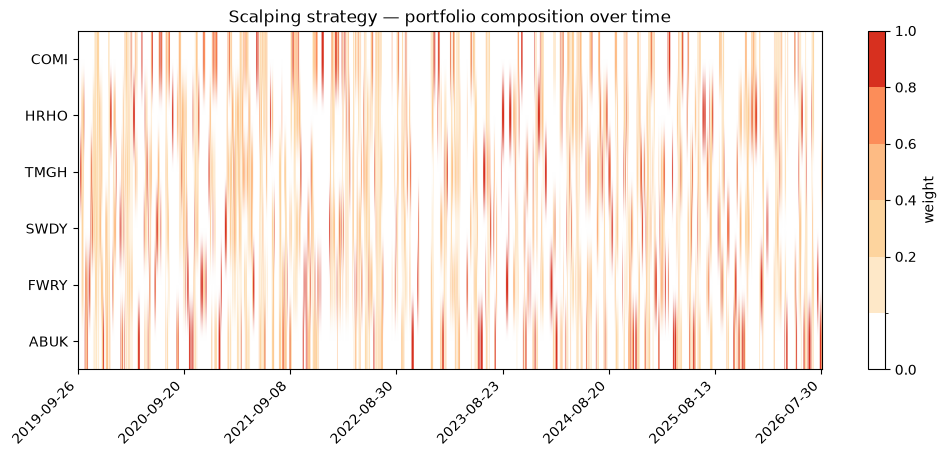

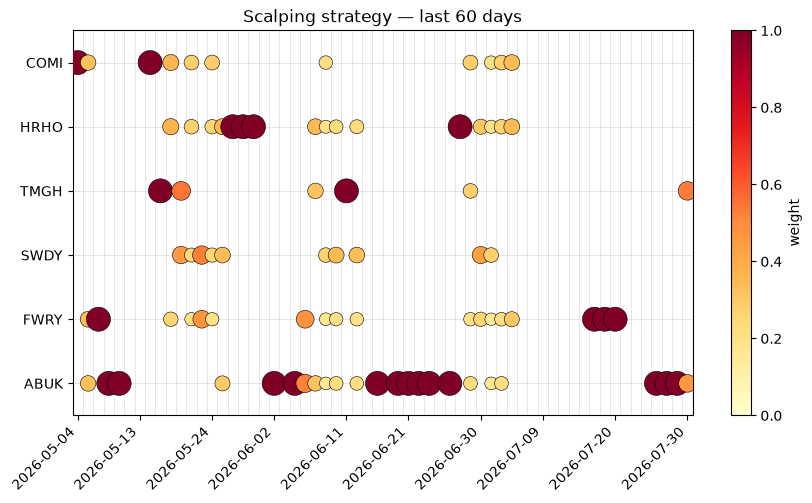

In [12]:
from tradinglab.charting import plot_portfolio_composition_discrete, plot_portfolio_dots

plot_portfolio_composition_discrete(result['weights'], result['dates'], feed.symbols,
                                     title='Scalping strategy — portfolio composition over time')
plt.show()

plot_portfolio_dots(result['weights'][-60:], result['dates'][-60:], feed.symbols,
                     title='Scalping strategy — last 60 days')
plt.show()

## 6. Report — equity curve, Sharpe, drawdown, win rate

`report()` gives the same scorecard as every notebook this week: total return,
Sharpe, max drawdown, and the equity curve against the real EGX30 benchmark. Win
rate isn't part of `report()` (it only applies to strategies that trade in
discrete positions), so it's printed alongside it — same numbers, same honesty,
one extra line that means something specific to a strategy like this one.

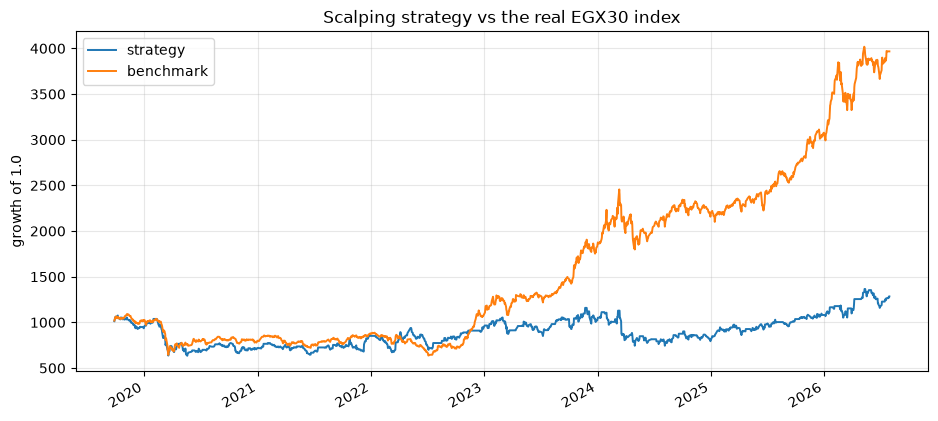

total return   : +28.4%
sharpe         : 0.28
max drawdown   : 41.0%
final value    : 1284.12   (benchmark 3967.15)
beat benchmark : no
                 you lost to the benchmark by 2,683 EGP

win rate (per closed trade) : 43.5%  (1211 trades)
sharpe (daily, from metrics): 0.28
max drawdown (from metrics) : 41.0%


In [13]:
from tradinglab.report import report
from tradinglab import metrics as met

START_CAPITAL = 1000.0
report(result, title='Scalping strategy vs the real EGX30 index', start_capital=START_CAPITAL)

r = result['portfolio_returns']
print(f'\nwin rate (per closed trade) : {win_rate:.1%}  ({len(trade_returns)} trades)')
print(f'sharpe (daily, from metrics): {met.sharpe(r):.2f}')
print(f'max drawdown (from metrics) : {met.max_drawdown(r):.1%}')

## 7. The catch — frequent trading has a cost

Every trade in the backtest above is free. Real trading isn't: a scalper that
flips positions every few days pays commission far more often than a
trend-follower that trades a handful of times a year. `PortfolioSimulator`
already models this — the `commission` parameter charges a cost proportional to
turnover, same simulator, no new code. Re-run the identical strategy through a
simulator with a small commission and see how much of the edge survives.

frictionless final value : 1284.12 EGP
with 10bps commission    : 679.33 EGP


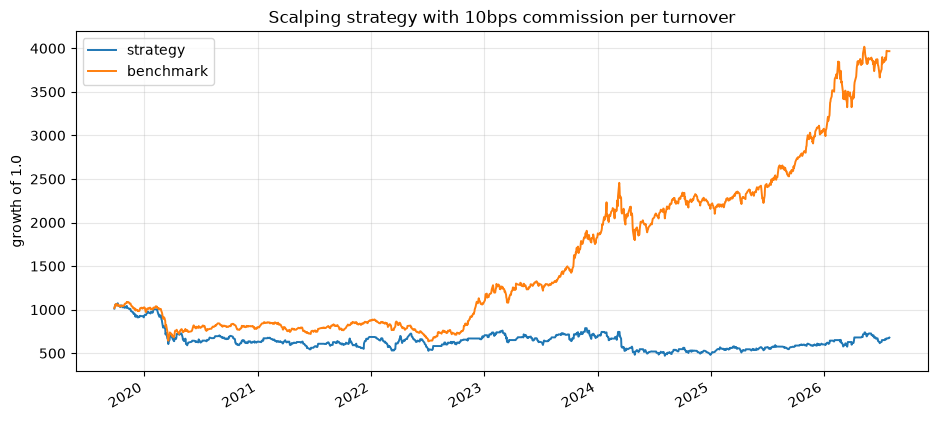

total return   : -32.1%
sharpe         : -0.08
max drawdown   : 56.2%
final value    : 679.33   (benchmark 3967.15)
beat benchmark : no
                 you lost to the benchmark by 3,288 EGP


In [14]:
sim_with_costs = PortfolioSimulator(feed, benchmark='egx30', commission=0.001)   # 10 bps per unit turnover
scalper_with_costs = ScalpingStrategy(entry_dip=0.015, profit_target=0.02, stop_loss=0.01,
                                       max_hold_days=5, max_weight_per_asset=0.5)
result_with_costs = run_backtest(sim_with_costs, scalper_with_costs, lookback=30)

print('frictionless final value :', round(result['portfolio'][-1] * START_CAPITAL, 2), 'EGP')
print('with 10bps commission    :', round(result_with_costs['portfolio'][-1] * START_CAPITAL, 2), 'EGP')
report(result_with_costs, title='Scalping strategy with 10bps commission per turnover',
       start_capital=START_CAPITAL)

## 8. Reflect

A scalper's edge, if it has one, comes from being right often on small moves —
which is exactly why win rate and trading costs matter here in a way they don't
for a strategy that trades a few times a year. Things worth trying:

- **Tighten `entry_dip`** (say 0.025 instead of 0.015): fewer, higher-conviction
  entries. Does win rate go up? Does total return?
- **Loosen `stop_loss` relative to `profit_target`**: a scalper that risks more
  than it targets needs a much higher win rate just to break even — check the
  math against the win rate you actually got.
- **Compare section 6 vs section 7** honestly: did the strategy still beat the
  benchmark once commission was applied? Frequent trading only pays for itself
  if the edge is bigger than the friction.

**Graduate it** into `src/tradinglab/strategies/scalping.py` if you want it on
the dashboard leaderboard alongside SMA and mean-reversion — same pattern as
everything else this week.